# # ML - 비지도학습 - Clustering 실습

[사용 제한 안내]
> 본 실습 코드는 교육 및 학습 목적으로만 제공됩니다.

[사전 준비 사항]
- 없음

[분석 요건]
- 분석 주제 : Clustering 기법을 활용한 고객 세분화 실습
- 분석 단위 : 고객
- 분석 변수 : 고객 연령, 소득, 소비

[주요 실습 내용]
- K-Means 군집 분석

# 데이타 준비
- 분석 데이타 : Mall Customers
- 데이타 설명 : 쇼핑몰 고객의 성별, 나이, 연간 소득, 소비 점수를 이용하여 유사한 고객 그룹을 찾기 위함
- 변수 설명

| 컬럼명                    | 한글명   | 의미                           | 비고      |
| ---------------------- | ----- | ---------------------------- | ------- |
| CustomerID             | 고객번호  | 고객 고유 식별번호                   | 식별자(ID) |
| Gender                 | 성별    | 고객의 성별(Male, Female)         | 범주형     |
| Age                    | 나이    | 고객의 나이(세)                    | 연속형     |
| Annual Income (k$)     | 연간 소득 | 고객의 연간 소득(천 달러 단위)           | 연속형     |
| Spending Score (1-100) | 소비 점수 | 쇼핑몰이 평가한 고객의 소비 성향 점수(1~100) | 연속형     |







데이타 불러오기

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

url = "https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2025%20-%20Hierarchical%20Clustering/Mall_Customers.csv"
df = pd.read_csv(url)
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


컬럼정보 확인

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


[참고] info()에서 확인할 것:
  - 총 행/열 수
  - 각 컬럼의 데이터 타입
    - int : 연속형 (정수형)
    - float : 연속형 (실수형)
    - object : 보통 문자열 (범주형)
    - category : 범주형,  *범주 갯수가 적을 경우 메모리 효율화를 위해 object 타입 대신 사용, 그러나 object 을 사용해도 무방
    - datetime : 날짜형

# EDA

연속형 변수 기본 분포값 확인
 - 비즈니스관점에서 데이터 이상 여부 확인, 특히 음수(-), '0' 데이터 주의
 - Missing 건수 확인
 - 데이터 최소, 최대, 중심값 확인
 - 데이터 밀집도 확인

In [3]:
import numpy as np

# 연속형 변수 기본 분포 확인
df.select_dtypes(include=[np.number]).describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


범주형 변수 기본 분포값 확인
 - 비즈니스관점에서 데이터 이상 여부 확인
 - Missing 건수 확인
 - 데이터 밀집도 확인
 - 범주 갯수 확인

In [4]:
# 범주형 변수 자동 추출
cat_cols = df.select_dtypes(include=['object', 'category']).columns

# 범주 건수 & 비율 계산
for col in cat_cols:
    print(f"\n[{col}]")
    dist = df[col].value_counts(dropna=False)
    ratio = df[col].value_counts(normalize=True, dropna=False) * 100
    result = pd.DataFrame({
        "count": dist,
        "ratio_%": ratio.round(2)
    })
    print(result)


[Genre]
        count  ratio_%
Genre                 
Female    112     56.0
Male       88     44.0


/var/folders/14/gczk6h2n7nb_w800tdh9mtb40000gn/T/ipykernel_449/2971682825.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns


소득과 소비 관계 탐색


소득과 소비 점수 관계:


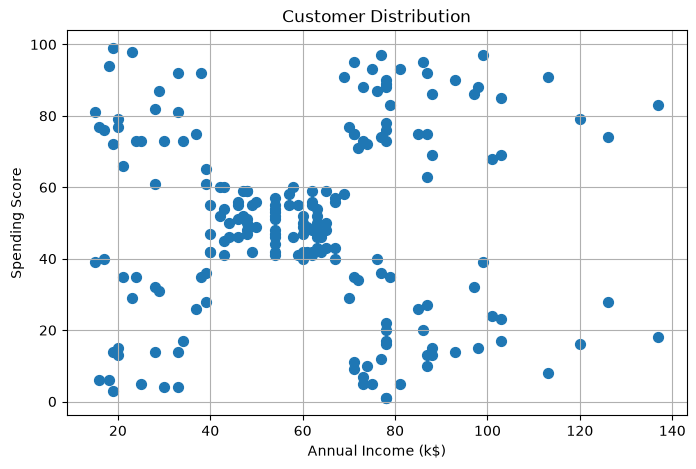

In [5]:
# 산점도로 소득과 소비 점수 관계 확인
print("\n소득과 소비 점수 관계:")
plt.figure(figsize=(8, 5))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], s=50)
plt.title('Customer Distribution')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.grid(True)
plt.show()

# 군집 분석

분석 변수 선택

In [7]:
# 소득과 소비 점수만 사용
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

Scaling
- Z-Score 변환

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

최적 군집수 (K) 분석
 - Elbow 차트

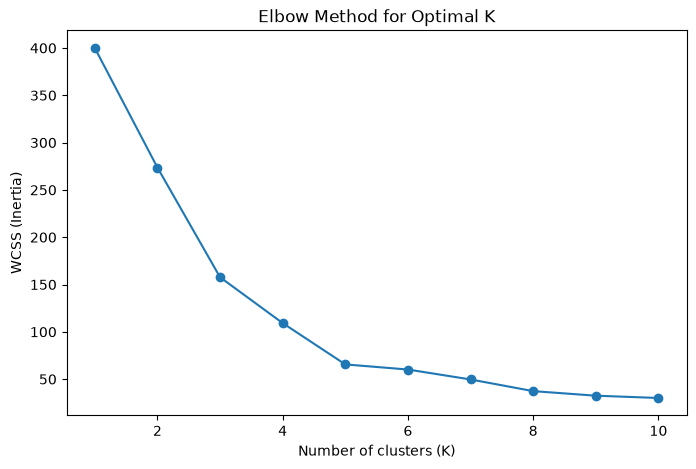

In [16]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []  # Within-Cluster Sum of Squares

K_range = range(1, 11)  # 보통 1~10

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# 엘보 차트
plt.figure(figsize=(8,5))
plt.plot(K_range, wcss, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method for Optimal K")
plt.show()

K-Means 군집 분석
 - K=5

In [10]:
from sklearn.cluster import KMeans

# K-means 모델 정의
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)

# 군집 학습 + 예측 (라벨 생성)
labels = kmeans.fit_predict(X_scaled)

# 원래 데이타에 군집 라벨 추가
df['cluster'] = labels
df


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,3
197,198,Male,32,126,74,1
198,199,Male,32,137,18,3


- 군집 시각화

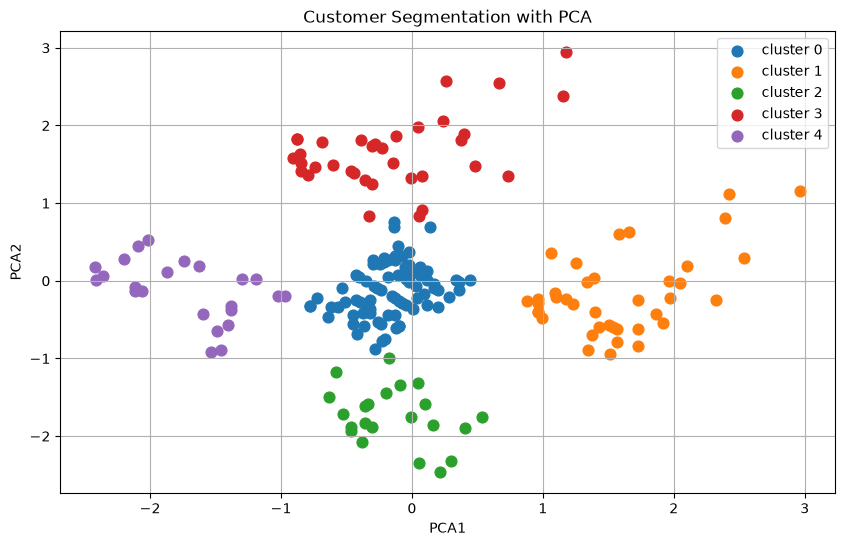

In [11]:
from sklearn.decomposition import PCA

# PCA 차원축소
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

# PCA 기반 군집 시각화
plt.figure(figsize=(10, 6))

for i in range(k):
    cluster_data = df[df["cluster"] == i]
    plt.scatter(
        cluster_data["PCA1"],
        cluster_data["PCA2"],
        label=f"cluster {i}",
        s=60
    )

plt.title("Customer Segmentation with PCA")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.legend()
plt.grid(True)
plt.show()

 - 군집 특성 분석 (EDA)

In [12]:
# 각 군집의 특성 확인
cluster_summary = df.groupby('cluster').agg({
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'Age': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'Count'})

print(cluster_summary.round(1))

         Annual Income (k$)  Spending Score (1-100)   Age  Count
cluster                                                         
0                      55.3                    49.5  42.7     81
1                      86.5                    82.1  32.7     39
2                      25.7                    79.4  25.3     22
3                      88.2                    17.1  41.1     35
4                      26.3                    20.9  45.2     23


 - 군집 비지니스 해석 (예시)

In [13]:
import pandas as pd

marketing = pd.DataFrame({
    "군집": [0, 1, 2, 3, 4],
    "특성": [
        "소득·소비 모두 평균 수준",
        "소득 높음 · 소비 높음",
        "소득 낮음 · 소비 높음",
        "소득 높음 · 소비 낮음",
        "소득 낮음 · 소비 낮음",

    ],
    "별명": [
        "평균 고객",
        "VIP 고객",
        "트렌드 추종자",
        "잠재 고객",
        "일반 고객",

    ],
    "마케팅 전략": [
        "대중적인 상품 추천 및 일반 프로모션 운영",
        "프리미엄 상품 추천, VIP 멤버십 및 맞춤형 혜택 제공",
        "저가·트렌디 상품 추천, 시즌 이벤트 활용",
        "할인 쿠폰, 프로모션 등을 통해 구매 유도",
        "필수품 중심의 실속형 상품 및 할인 행사 제공",

    ]
})

marketing

,군집,특성,별명,마케팅 전략
0,0,소득·소비 모두 평균 수준,평균 고객,대중적인 상품 추천 및 일반 프로모션 운영
1,1,소득 높음 · 소비 높음,VIP 고객,"프리미엄 상품 추천, VIP 멤버십 및 맞춤형 혜택 제공"
2,2,소득 낮음 · 소비 높음,트렌드 추종자,"저가·트렌디 상품 추천, 시즌 이벤트 활용"
3,3,소득 높음 · 소비 낮음,잠재 고객,"할인 쿠폰, 프로모션 등을 통해 구매 유도"
4,4,소득 낮음 · 소비 낮음,일반 고객,필수품 중심의 실속형 상품 및 할인 행사 제공


### [Self-Practice]

- 실습 조건
  - 분석 변수에 'Age' 를 추가해서 3개 변수를 활용 ('Age', 'Annual Income (k$)', 'Spending Score (1-100)')
- 실습 시나리오  
   - 시나리오 1) Elbow 차트에서 최적 K를 찾고, 2개 변수만 사용한 경우와 비교하기
   - 시나리오 2) 최적 K 기준으로 군집분석을 수행한 후 2개 변수와 3개 변수 활용 시 군집 시각화 결과의 차이를 비교하세요.
   - 시나리오 3) 각 군집별 특성을 분석하고, 비지니스 해석하기 (연령 포함한 해석)

In [17]:
# 소득과 소비 점수만 사용
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

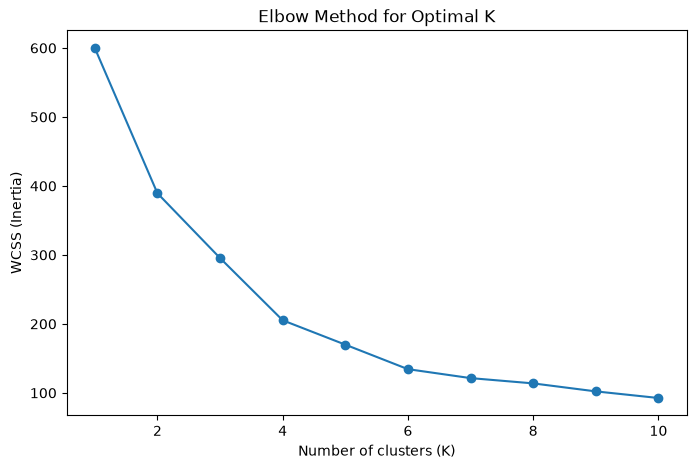

In [19]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []  # Within-Cluster Sum of Squares

K_range = range(1, 11)  # 보통 1~10

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# 엘보 차트
plt.figure(figsize=(8,5))
plt.plot(K_range, wcss, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method for Optimal K")
plt.show()

In [24]:
from sklearn.cluster import KMeans

# K-means 모델 정의
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)

# 군집 학습 + 예측 (라벨 생성)
labels = kmeans.fit_predict(X_scaled)

# 원래 데이타에 군집 라벨 추가
df['cluster'] = labels
df


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster,PCA1,PCA2
0,1,Male,19,15,39,2,-0.615720,-1.763481
1,2,Male,21,15,81,2,-1.665793,-1.820747
2,3,Female,20,16,6,2,0.337862,-1.674799
3,4,Female,23,16,77,2,-1.456573,-1.772430
4,5,Female,31,17,40,2,-0.038465,-1.662740
...,...,...,...,...,...,...,...,...
195,196,Female,35,120,79,1,-1.093705,2.215577
196,197,Female,45,126,28,3,0.800448,2.540748
197,198,Male,32,126,74,1,-1.119709,2.445169
198,199,Male,32,137,18,3,0.395411,2.946665


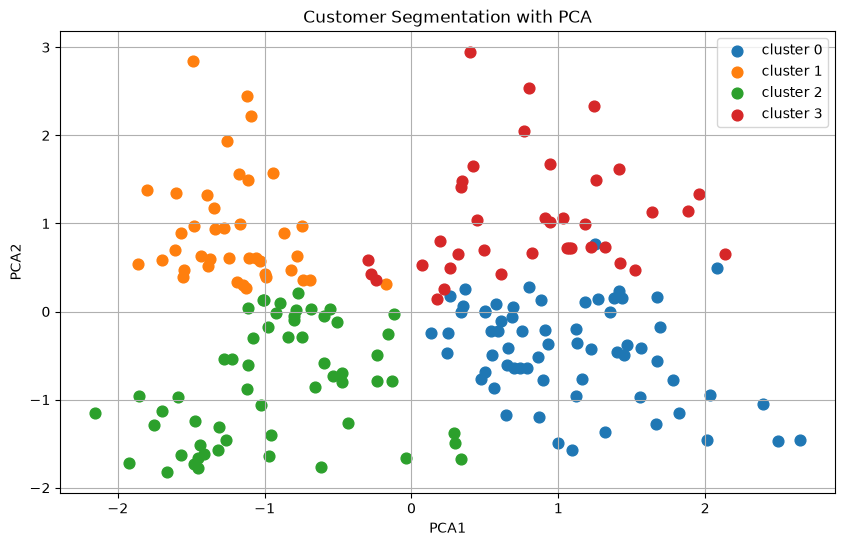

In [25]:
from sklearn.decomposition import PCA

# PCA 차원축소
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

# PCA 기반 군집 시각화
plt.figure(figsize=(10, 6))

for i in range(k):
    cluster_data = df[df["cluster"] == i]
    plt.scatter(
        cluster_data["PCA1"],
        cluster_data["PCA2"],
        label=f"cluster {i}",
        s=60
    )

plt.title("Customer Segmentation with PCA")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
# 각 군집의 특성 확인
cluster_summary = df.groupby('cluster').agg({
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'Age': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'Count'})

print(cluster_summary.round(1))

         Annual Income (k$)  Spending Score (1-100)   Age  Count
cluster                                                         
0                      47.7                    40.0  54.0     65
1                      86.1                    81.5  32.9     40
2                      40.0                    60.3  25.4     57
3                      86.5                    19.6  39.4     38


0: 중간 소득의 50대 중반의 소비 점수는 낮음

1: 고소득의 30대 초반의 소비 점수는 높음

2: 저소득의 20대 중반의 소비 점수는 높음

3: 고소득의 30대 후반의 소비 점수는 낮음